In [2]:
from pathlib import Path
import os

PROJECT_ROOT = Path().resolve().parent
CACHE_DIR = PROJECT_ROOT / "data" / "raw"

CACHE_DIR.mkdir(parents=True, exist_ok=True)

os.environ["KAGGLEHUB_CACHE"] = str(CACHE_DIR)

import kagglehub

path = kagglehub.dataset_download("clmentbisaillon/fake-and-real-news-dataset")
print(path)

E:\digitalfutures\VSCode\repo\capstone-project\data\raw\datasets\clmentbisaillon\fake-and-real-news-dataset\versions\1


In [3]:
from pathlib import Path
import pandas as pd
import os

path = Path(path)

df_fake = pd.read_csv(path / "Fake.csv")
df_true = pd.read_csv(path / "True.csv")

In [4]:
df_fake.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [5]:
df_fake = df_fake.assign(label="0")
df_true = df_true.assign(label="1")

In [6]:
df_fake = df_fake.drop(columns=["subject", "date"])
df_true = df_true.drop(columns=["subject", "date"])

In [7]:
df_news = pd.concat([df_fake, df_true], ignore_index=True)
df_news

,title,text,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,0
...,...,...,...
44893,'Fully committed' NATO backs new U.S. approach...,BRUSSELS (Reuters) - NATO allies on Tuesday we...,1
44894,LexisNexis withdrew two products from Chinese ...,"LONDON (Reuters) - LexisNexis, a provider of l...",1
44895,Minsk cultural hub becomes haven from authorities,MINSK (Reuters) - In the shadow of disused Sov...,1
44896,Vatican upbeat on possibility of Pope Francis ...,MOSCOW (Reuters) - Vatican Secretary of State ...,1


In [8]:
df_news.isnull().sum()

title    0
text     0
label    0
dtype: int64

In [9]:
df_news.duplicated().sum()

np.int64(5793)

In [10]:
df_news.drop_duplicates(inplace=True)

In [11]:
import re
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import numpy as np

nltk.download('wordnet', "/kaggle/working/nltk_data/")
nltk.download('omw-1.4', "/kaggle/working/nltk_data/")
nltk.download('punkt_tab', "/kaggle/working/nltk_data/")
nltk.download('stopwords', "/kaggle/working/nltk_data/")

[nltk_data] Downloading package wordnet to
[nltk_data]     /kaggle/working/nltk_data/...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /kaggle/working/nltk_data/...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /kaggle/working/nltk_data/...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /kaggle/working/nltk_data/...
[nltk_data]   Package stopwords is already up-to-date!


True

In [12]:
import zipfile
import os

zip_paths = [
    "/kaggle/working/nltk_data/corpora/wordnet.zip",
    "/kaggle/working/nltk_data/corpora/omw-1.4.zip",
    "/kaggle/working/nltk_data/tokenizers/punkt_tab.zip",
    "/kaggle/working/nltk_data/corpora/stopwords.zip"
]

extract_dir = "/kaggle/working/nltk_data/corpora"

os.makedirs(extract_dir, exist_ok=True)

for z in zip_paths:
    with zipfile.ZipFile(z, "r") as zip_ref:
        zip_ref.extractall(extract_dir)
nltk.data.path.append("/kaggle/working/nltk_data/")

In [13]:
def process_text(text):
    text = re.sub(
        r"\s+", " ", text, flags=re.I
    )  # Remove extra white space from text

    text = re.sub(
        r"\W", " ", str(text)
    )  # Remove all the special characters from text

    text = re.sub(
        r"\s+[a-zA-Z]\s+", " ", text
    )  # Remove all single characters from text

    text = re.sub(
        r"[^a-zA-Z\s]", "", text
    )  # Remove any character that isn't alphabetical

    text = text.lower()

    words = word_tokenize(text)

    lemmatizer = WordNetLemmatizer()
    words = [lemmatizer.lemmatize(word) for word in words]

    stop_words = set(stopwords.words("english"))
    Words = [word for word in words if word not in stop_words]

    Words = [word for word in Words if len(word) > 3]

    indices = np.unique(Words, return_index=True)[1]
    cleaned_text = np.array(Words)[np.sort(indices)].tolist()

    return cleaned_text

In [14]:
x = df_news.drop("label", axis=1)
y = df_news.label

In [15]:
texts = list(x["text"])

In [16]:
cleaned_text = [process_text(text) for text in texts]

In [17]:
print(cleaned_text[:5])

[['donald', 'trump', 'wish', 'american', 'happy', 'year', 'leave', 'instead', 'give', 'shout', 'enemy', 'hater', 'dishonest', 'fake', 'news', 'medium', 'former', 'reality', 'show', 'star', 'country', 'rapidly', 'grows', 'stronger', 'smarter', 'want', 'friend', 'supporter', 'even', 'healthy', 'president', 'angry', 'pant', 'tweeted', 'great', 'america', 'realdonaldtrump', 'december', 'tweet', 'went', 'welll', 'expect', 'kind', 'sends', 'greeting', 'like', 'despicable', 'petty', 'infantile', 'gibberish', 'lack', 'decency', 'allow', 'rise', 'gutter', 'long', 'enough', 'citizen', 'bishop', 'talbert', 'swan', 'talbertswan', 'calvin', 'calvinstowell', 'impeachment', 'would', 'make', 'also', 'accept', 'regaining', 'control', 'congress', 'miranda', 'yaver', 'mirandayaver', 'hear', 'talk', 'include', 'many', 'people', 'hate', 'wonder', 'alan', 'sandoval', 'alansandoval', 'word', 'marlene', 'koren', 'pollitt', 'korencarpenter', 'including', 'fought', 'lost', 'badly', 'know', 'love', 'nothing', 'd

In [18]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    cleaned_text, y, test_size=0.2, random_state=42
)

In [19]:
from collections import Counter
from dataclasses import dataclass
import torch
import pickle


def pad_sequence(sequences, batch_first=True, padding_value=0):
    if len(sequences) == 0:
        raise ValueError("pad_sequence: 'sequences' must be a non-empty list")
    max_len = max(seq.size(0) for seq in sequences)
    trailing_dims = sequences[0].size()[1:]
    dtype = sequences[0].dtype
    device = sequences[0].device
    if batch_first:
        out_dims = (len(sequences), max_len) + trailing_dims
        out = torch.full(out_dims, padding_value, dtype=dtype, device=device)
        for i, seq in enumerate(sequences):
            length = seq.size(0)
            out[i, :length, ...] = seq
    else:
        out_dims = (max_len, len(sequences)) + trailing_dims
        out = torch.full(out_dims, padding_value, dtype=dtype, device=device)
        for i, seq in enumerate(sequences):
            length = seq.size(0)
            out[:length, i, ...] = seq
    return out


def tokenize(t):
    if isinstance(t, str):
        return t.split()
    elif isinstance(t, (list, tuple)):
        return list(t)
    else:
        raise TypeError(f"Unsupported type for tokenize: {type(t)}")


def iter_tokens(x):
    for item in x:
        yield tokenize(item)


@dataclass
class SimpleVocab:
    stoi: dict
    itos: list
    _default_index: int | None = None

    def __getitem__(self, token):
        if token in self.stoi:
            return self.stoi[token]
        if self._default_index is not None:
            return self._default_index
        raise KeyError(token)

    def set_default_index(self, idx: int):
        self._default_index = idx

    def __len__(self):
        return len(self.itos)


def build_vocab_from_iterator_simple(iterator, specials=None):
    if specials is None:
        specials = []
    counter = Counter()
    for tokens in iterator:
        counter.update(tokens)
    stoi = {}
    itos = []
    for sp in specials:
        if sp not in stoi:
            stoi[sp] = len(itos)
            itos.append(sp)
    for token, _ in counter.most_common():
        if token not in stoi:
            stoi[token] = len(itos)
            itos.append(token)
    return SimpleVocab(stoi=stoi, itos=itos)


vocab = build_vocab_from_iterator_simple(
    iter_tokens(x_train), specials=["<pad>", "<unk>"]
)
vocab.set_default_index(vocab["<unk>"])
print("the size of vocab =", len(vocab))

with open("vocab.pkl", "wb") as f:
    pickle.dump(vocab, f)


def to_seq(x, v):
    out = []
    for t in x:
        tokens = tokenize(t)
        out.append(
            torch.tensor([v[token] for token in tokens], dtype=torch.long)
        )
    return out


train_seq = to_seq(x_train, vocab)
test_seq = to_seq(x_test, vocab)

pad_idx = vocab["<pad>"]
x_train = pad_sequence(train_seq, batch_first=True, padding_value=pad_idx)
x_test = pad_sequence(test_seq, batch_first=True, padding_value=pad_idx)

the size of vocab = 91459


In [20]:
maxlen = 200
pad_value = vocab["<pad>"]

x_train = torch.nn.functional.pad(
    x_train[:, :maxlen], (0, max(0, maxlen - x_train.size(1))), value=pad_value
)

x_test = torch.nn.functional.pad(
    x_test[:, :maxlen], (0, max(0, maxlen - x_test.size(1))), value=pad_value
)

In [21]:
y.value_counts()

label
1    21197
0    17908
Name: count, dtype: int64

In [56]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

with open("label_encoder.pkl", "wb") as f:
    pickle.dump(label_encoder, f)

In [57]:
import torch

y_train_encoded = torch.tensor(y_train_encoded, dtype=torch.long)
y_test_encoded = torch.tensor(y_test_encoded, dtype=torch.long)

num_classes = len(torch.unique(y_train_encoded))

y_train_one_hot = torch.nn.functional.one_hot(
    y_train_encoded, num_classes=num_classes
).float()

y_test_one_hot = torch.nn.functional.one_hot(
    y_test_encoded, num_classes=num_classes
).float()

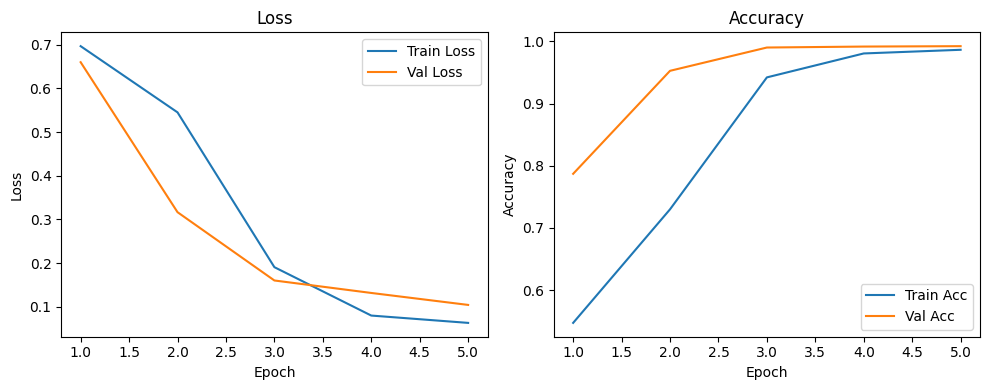

Epoch 5/5 - Time: 22.13s - Train Loss: 0.0629, Train Acc: 0.9864 - Val Loss: 0.1041, Val Acc: 0.9922


In [61]:
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import torch_directml
import matplotlib.pyplot as plt
from IPython.display import clear_output
from tqdm.auto import tqdm

device = torch_directml.device(torch_directml.default_device())
print("Device:", device)


class ModelPT(nn.Module):
    def __init__(self, vocab_size, maxlen):
        super().__init__()
        emb_dim = 128
        hidden_dim = 256
        self.emb = nn.Embedding(vocab_size + 1, emb_dim)
        self.drop1 = nn.Dropout(0.5)
        self.conv1 = nn.Conv1d(emb_dim, hidden_dim, kernel_size=3, padding=1)
        self.drop2 = nn.Dropout(0.5)
        self.fc1 = nn.Linear(hidden_dim, 128)
        self.drop3 = nn.Dropout(0.5)
        self.fc2 = nn.Linear(128, 2)

    def forward(self, x):
        x = self.emb(x)
        x = self.drop1(x)
        x = x.transpose(1, 2)
        x = self.conv1(x)
        x = torch.relu(x)
        x = self.drop2(x)
        x = x.max(dim=2).values
        x = torch.relu(self.fc1(x))
        x = self.drop3(x)
        return self.fc2(x)


vocab_size = len(vocab)

class_counts = torch.bincount(y_train_encoded)
weights = 1.0 / class_counts.float()
weights = weights / weights.sum()

model = ModelPT(vocab_size=vocab_size, maxlen=maxlen).to(device)
criterion = nn.CrossEntropyLoss(weight=weights.to(device)).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-4)

train_ds = TensorDataset(x_train.cpu(), y_train_encoded.cpu())
test_ds = TensorDataset(x_test.cpu(), y_test_encoded.cpu())

train_dl = DataLoader(
    train_ds,
    batch_size=128,
    shuffle=True,
    num_workers=4,
    persistent_workers=True,
)
test_dl = DataLoader(
    test_ds,
    batch_size=256,
    shuffle=False,
    num_workers=4,
    persistent_workers=True,
)

train_acc_hist, val_acc_hist = [], []
train_loss_hist, val_loss_hist = [], []

num_epochs = 5
best_loss = float("inf")

for epoch in range(1, num_epochs + 1):
    model.train()
    correct = 0
    total = 0
    running_loss = 0.0
    epoch_start = time.time()

    train_bar = tqdm(
        train_dl, desc=f"Epoch {epoch}/{num_epochs} [train]", unit="batch"
    )
    for xb_cpu, yb_cpu in train_bar:
        xb = xb_cpu.to(device, non_blocking=True)
        yb = yb_cpu.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        out = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        preds = out.argmax(1)
        correct += (preds == yb).sum().item()
        total += yb.size(0)
        train_bar.set_postfix(loss=f"{loss.item():.4f}")

    train_acc = correct / total
    train_loss = running_loss / len(train_dl)
    epoch_time = time.time() - epoch_start

    model.eval()
    correct = 0
    total = 0
    running_loss = 0.0

    val_bar = tqdm(
        test_dl, desc=f"Epoch {epoch}/{num_epochs} [val]", unit="batch"
    )
    with torch.no_grad():
        for xb_cpu, yb_cpu in val_bar:
            xb = xb_cpu.to(device, non_blocking=True)
            yb = yb_cpu.to(device, non_blocking=True)
            out = model(xb)
            loss = criterion(out, yb)
            running_loss += loss.item()
            preds = out.argmax(1)
            correct += (preds == yb).sum().item()
            total += yb.size(0)
            val_bar.set_postfix(loss=f"{loss.item():.4f}")

    val_acc = correct / total
    val_loss = running_loss / len(test_dl)

    train_acc_hist.append(train_acc)
    val_acc_hist.append(val_acc)
    train_loss_hist.append(train_loss)
    val_loss_hist.append(val_loss)

    if val_loss < best_loss:
        best_loss = val_loss
        torch.save(model.state_dict(), "best_model.pt")
        print(f"Saved best model (val_loss={best_loss:.4f})")

    clear_output(wait=True)
    epochs_range = range(1, epoch + 1)

    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, train_loss_hist, label="Train Loss")
    plt.plot(epochs_range, val_loss_hist, label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, train_acc_hist, label="Train Acc")
    plt.plot(epochs_range, val_acc_hist, label="Val Acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Accuracy")
    plt.legend()

    plt.tight_layout()
    plt.show()

    print(
        f"Epoch {epoch}/{num_epochs} "
        f"- Time: {epoch_time:.2f}s "
        f"- Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} "
        f"- Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}"
    )

In [62]:
import torch
import torch_directml

device = torch_directml.device(torch_directml.default_device())
model.to(device)
model.eval()


def tokenize(t):
    return t.split()


def encode_sequence(text, vocab):
    return [vocab[token] for token in tokenize(text)]


def pad_to_maxlen(ids, pad_idx, maxlen):
    if len(ids) >= maxlen:
        return ids[:maxlen]
    return ids + [pad_idx] * (maxlen - len(ids))


def predict_text(samples):
    pad_idx = vocab["<pad>"]
    encoded = []
    for text in samples:
        ids = encode_sequence(text, vocab)
        ids = pad_to_maxlen(ids, pad_idx, maxlen)
        encoded.append(ids)
    x = torch.tensor(encoded, dtype=torch.long, device=device)
    with torch.no_grad():
        logits = model(x)
        probs = torch.softmax(logits, dim=-1)
        preds = probs.argmax(dim=-1)
    for i, text in enumerate(samples):
        print(preds[i].item())
        print(probs[i].tolist())
        print()

In [79]:
import requests
from bs4 import BeautifulSoup


def get_article_text(url):
    r = requests.get(url, timeout=10)
    r.raise_for_status()
    soup = BeautifulSoup(r.text, "html.parser")
    parts = []
    for p in soup.find_all("p"):
        text = p.get_text(strip=True)
        if text:
            parts.append(text)
    return "\n".join(parts)


url = "https://edition.cnn.com/2025/11/27/entertainment/stranger-things-season-5-recap-tvrep"
article_text = get_article_text(url)
predict_text([article_text])

0
[0.7116851806640625, 0.2883148491382599]



In [80]:
import torch
import torch_directml

device = torch_directml.device(torch_directml.default_device())
model.to(device)
model.eval()


def test_on_real_test_data(n=10):
    idx = torch.randint(0, x_test.size(0), (n,))
    xb = x_test[idx].to(device)
    yb = y_test_encoded[idx].to(device)

    with torch.no_grad():
        logits = model(xb)
        probs = torch.softmax(logits, dim=-1)
        preds = probs.argmax(dim=-1)

    correct = (preds == yb).sum().item()

    for i in range(n):
        print("INDEX:", int(idx[i].item()))
        print("TRUE_CLASS:", int(yb[i].item()))
        print("PRED_CLASS:", int(preds[i].item()))
        print("PROBS:", probs[i].tolist())
        print()

    print("SAMPLE ACCURACY:", f"{(correct / n) * 100:.2f}%")


test_on_real_test_data(10)

INDEX: 2112
TRUE_CLASS: 0
PRED_CLASS: 0
PROBS: [0.7617282271385193, 0.23827184736728668]

INDEX: 4774
TRUE_CLASS: 1
PRED_CLASS: 1
PROBS: [0.00011796666512964293, 0.9998819828033447]

INDEX: 2268
TRUE_CLASS: 1
PRED_CLASS: 1
PROBS: [0.00024214563018176705, 0.9997578263282776]

INDEX: 7564
TRUE_CLASS: 1
PRED_CLASS: 1
PROBS: [0.0001163217457360588, 0.9998836517333984]

INDEX: 2322
TRUE_CLASS: 1
PRED_CLASS: 1
PROBS: [0.0009970074752345681, 0.999002993106842]

INDEX: 494
TRUE_CLASS: 0
PRED_CLASS: 0
PROBS: [0.8307591676712036, 0.16924087703227997]

INDEX: 6496
TRUE_CLASS: 1
PRED_CLASS: 1
PROBS: [0.00017503001436125487, 0.9998249411582947]

INDEX: 477
TRUE_CLASS: 0
PRED_CLASS: 0
PROBS: [0.7739570736885071, 0.22604291141033173]

INDEX: 4789
TRUE_CLASS: 0
PRED_CLASS: 0
PROBS: [0.9694126844406128, 0.030587296932935715]

INDEX: 5323
TRUE_CLASS: 0
PRED_CLASS: 1
PROBS: [0.0001667539036134258, 0.9998332262039185]

SAMPLE ACCURACY: 90.00%


In [83]:
import pandas as pd
import torch
import torch_directml

device = torch_directml.device(torch_directml.default_device())
model.to(device)
model.eval()

df = pd.read_csv("fake_or_real_news.csv")

texts = df["text"].astype(str).tolist()
labels = df["label"].map({"FAKE": 0, "REAL": 1}).tolist()

pad_idx = vocab["<pad>"]


def encode_seq(t):
    ids = [vocab[token] for token in t.split()]
    if len(ids) >= maxlen:
        return ids[:maxlen]
    return ids + [pad_idx] * (maxlen - len(ids))


encoded = [encode_seq(t) for t in texts]

x = torch.tensor(encoded, dtype=torch.long, device=device)
y = torch.tensor(labels, dtype=torch.long, device=device)

with torch.no_grad():
    logits = model(x)
    preds = logits.argmax(dim=1)
    acc = (preds == y).float().mean().item() * 100

print(f"DATASET ACCURACY: {acc:.2f}%")

DATASET ACCURACY: 49.91%
